# 산학프로젝트
**제조 공정 품질 불량 예측**

# 04_1_Imbalance_and_Feature_Experiments

## import

In [1]:
import pandas as pd
import numpy as np
import os

## 경로설정

In [2]:
os.chdir("data")

## 데이터 불러오기

In [3]:
labeled=pd.read_csv('labeled_data.csv', encoding='utf-8')
result_df=pd.read_csv('03_Baseline_Modeling_Result.csv')

In [4]:
labeled.head()

,_id,TimeStamp,PART_FACT_PLAN_DATE,PART_FACT_SERIAL,PART_NAME,EQUIP_CD,EQUIP_NAME,PassOrFail,Reason,Injection_Time,...,Mold_Temperature_3,Mold_Temperature_4,Mold_Temperature_5,Mold_Temperature_6,Mold_Temperature_7,Mold_Temperature_8,Mold_Temperature_9,Mold_Temperature_10,Mold_Temperature_11,Mold_Temperature_12
0,5f8928bb9c0189cc666ef19b,2020-10-16 04:57:47,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,...,24.799999,27.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,5f8928de9c0189cc666ef20b,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.60,...,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,5f8928df9c0189cc666ef213,2020-10-16 04:58:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.60,...,24.799999,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,5f8928f39c0189cc666ef25e,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,23,CN7 W/S SIDE MLD'G LH,S14,650톤-우진2호기,Y,NaN,9.59,...,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5f8928f59c0189cc666ef265,2020-10-16 04:59:48,2020-10-16 오전 12:00:00,24,CN7 W/S SIDE MLD'G RH,S14,650톤-우진2호기,Y,NaN,9.59,...,25.000000,27.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
result_df

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109


## 모델 개선 실험

In [6]:
# 개선 실험 공통 라이브러리
from pathlib import Path
import sys

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn import set_config
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score, classification_report
from xgboost import XGBClassifier

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'data' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 공통 평가 및 튜닝 함수
from utils.model_evaluation import evaluate_models, show_random_forest_feature_importance
from utils.model_tuning import grid_search_random_forest_smote

set_config(display='text')

### 클래스 가중치

#### 데이터 전처리

In [7]:
def info_df(df):
    info=pd.DataFrame(
        {
            "Columns": df.columns,
            "Non-Null Count": df.notna().sum().values,
            "Dtype": df.dtypes.values
        }
    )
    return info

In [8]:
info_df(labeled)

,Columns,Non-Null Count,Dtype
0,_id,7996,str
1,TimeStamp,7996,str
2,PART_FACT_PLAN_DATE,7996,str
3,PART_FACT_SERIAL,7996,int64
4,PART_NAME,7996,str
5,EQUIP_CD,7996,str
6,EQUIP_NAME,7996,str
7,PassOrFail,7996,str
8,Reason,71,str
9,Injection_Time,7996,float64


In [9]:
# 중복값 제거
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)

# CN7, RG3 제외 삭제
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

# 불필요한 변수 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2',
               'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL',
               'PART_NAME', 'Reason', 'Switch_Over_Position', 'TimeStamp', '_id']

final_df=drop_part.drop(columns=drop_columns)

# PassOrFail 인코딩
final_df['PassOrFail']=final_df['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

final_df.shape

(5230, 25)

In [10]:
final_df.head()

,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,9.59,4.47,16.92,59.520000,7.13,653.409973,68.849998,647.98999,55.400002,...,59.299999,276.500000,274.700012,274.799988,269.200012,255.000000,229.699997,66.300003,24.799999,27.5
1,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,...,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
2,0,9.60,4.48,16.91,59.580002,7.13,653.409973,68.839996,647.98999,55.299999,...,59.299999,276.200012,275.500000,275.299988,270.799988,254.699997,229.500000,67.199997,24.799999,27.6
3,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,...,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6
4,0,9.59,4.48,16.91,59.560001,7.13,653.419983,68.839996,647.98999,55.299999,...,59.299999,276.500000,275.000000,275.399994,271.100006,254.899994,230.000000,66.900002,25.000000,27.6


In [11]:
# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(final_df.drop(columns='PassOrFail'), final_df['PassOrFail'], test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

print("데이터 분할 결과")
print(f'X_Train: {x_train.shape}, Y_Train: {y_train.shape}')
print(f'X_Test: {x_test.shape}, Y_Test: {y_test.shape}')

# 데이터 스케일링
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

데이터 분할 결과
X_Train: (4184, 24), Y_Train: (4184,)
X_Test: (1046, 24), Y_Test: (1046,)


#### 모델 학습

In [12]:
model_dict={}
balanced_rf=RandomForestClassifier(n_estimators=1000, class_weight='balanced', min_samples_leaf=2, n_jobs=1, random_state=0)
balanced_rf.fit(x_train_scaled, y_train)
model_dict['RandomForest Balanced']=balanced_rf

#### 예측

RandomForest Balanced
Accuracy: 0.982791586998088
Average Precision: 0.3517577041256616
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.35      0.58      0.44        12

    accuracy                           0.98      1046
   macro avg       0.67      0.79      0.71      1046
weighted avg       0.99      0.98      0.98      1046



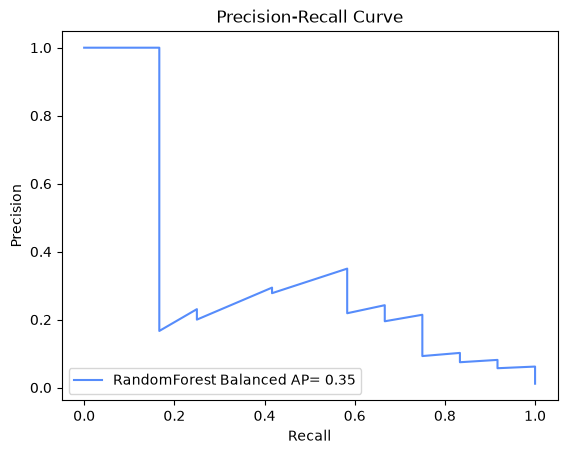

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.351758


In [13]:
# model_evaluation.py
result_df=evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest Balanced - Random Forest Feature Importance


,Feature,Importance
0,Plasticizing_Position,0.083095
1,Mold_Temperature_4,0.068282
2,Max_Injection_Speed,0.064592
3,Plasticizing_Time,0.059629
4,Mold_Temperature_3,0.057806
5,Injection_Time,0.057273
6,Average_Back_Pressure,0.056265
7,Max_Injection_Pressure,0.054154
8,Filling_Time,0.052039
9,Clamp_Close_Time,0.050265


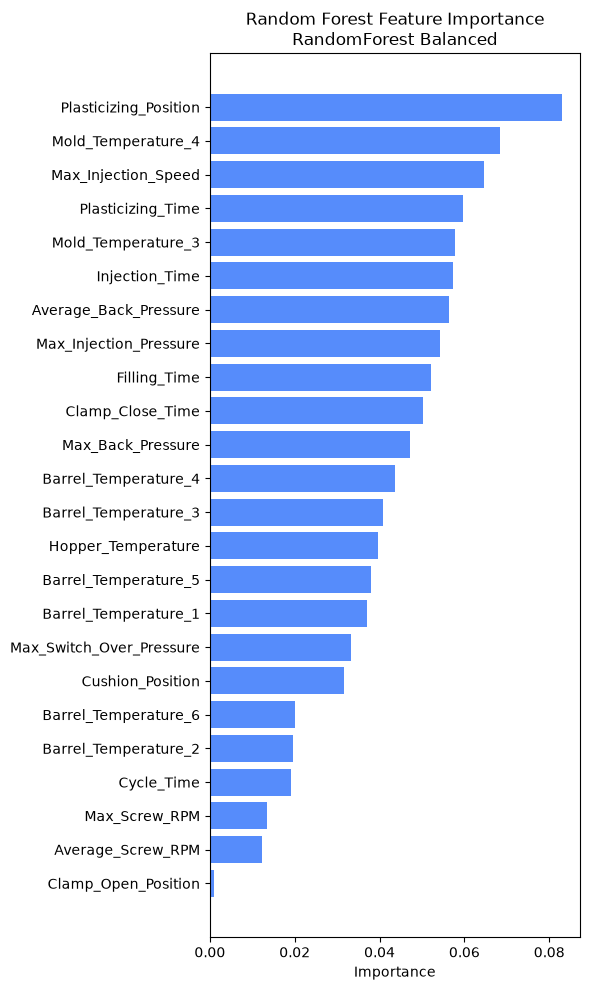

In [14]:
importance_tables = show_random_forest_feature_importance(
    model_dict, x_train.columns
)

### SMOTE: Sampling

#### 데이터 전처리

In [15]:
# 중복값 제거
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)

# CN7, RG3 제외 삭제
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

# 불필요한 변수 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2',
               'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL',
               'PART_NAME', 'Reason', 'Switch_Over_Position', 'TimeStamp', '_id']

final_df=drop_part.drop(columns=drop_columns)

# PassOrFail 인코딩
final_df['PassOrFail']=final_df['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

# 데이터 분할
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=y, random_state=0)

scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# 학습데이터에 SMOTE 적용
from imblearn.over_sampling import SMOTE

smote=SMOTE(random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4184, 24) (4184,)
After
(8272, 24) (8272,)


#### 모델 학습

In [16]:
# 학습 모델 저장
model_dict={} # evaluate_models가 for 문으로 작동하기 때문에 초기화 필요

# Random Forest
smote_rf=RandomForestClassifier(n_estimators=1000, random_state=0)
smote_rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest SMOTE']=smote_rf

# Bagging
smote_bag=BaggingClassifier(n_estimators=1000, random_state=0)
smote_bag.fit(x_train_smote, y_train_smote)
model_dict['Bagging SMOTE']=smote_bag

# XGBoost
smote_xgb=XGBClassifier(n_estimators=1000, random_state=0)
smote_xgb.fit(x_train_smote, y_train_smote)
model_dict['XGBoost SMOTE']=smote_xgb

#### 예측

RandomForest SMOTE
Accuracy: 0.9818355640535373
Average Precision: 0.45018302327062243
Classification Report
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.29      0.42      0.34        12

    accuracy                           0.98      1046
   macro avg       0.64      0.70      0.67      1046
weighted avg       0.99      0.98      0.98      1046

Bagging SMOTE
Accuracy: 0.9799235181644359
Average Precision: 0.4452438314400868
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.98      0.99      1034
          불량       0.30      0.58      0.40        12

    accuracy                           0.98      1046
   macro avg       0.65      0.78      0.69      1046
weighted avg       0.99      0.98      0.98      1046

XGBoost SMOTE
Accuracy: 0.9837476099426387
Average Precision: 0.3738407981735379
Classification Report
              precision    reca

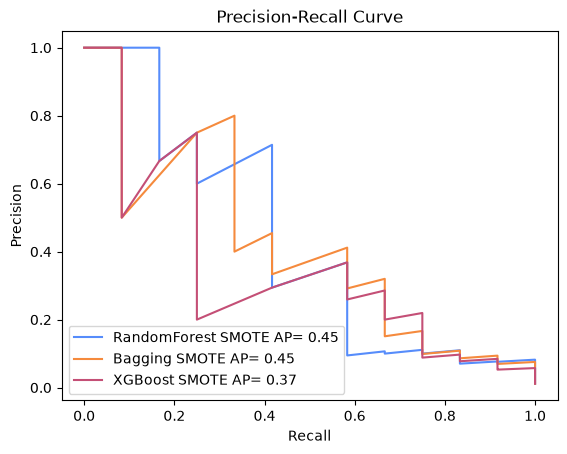

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.351758
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.450183
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.445244
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.373841


In [17]:
# model_dict의 키를 모델명으로 그대로 사용해 예측 및 평가
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest SMOTE - Random Forest Feature Importance


,Feature,Importance
0,Max_Injection_Speed,0.084952
1,Plasticizing_Position,0.074328
2,Mold_Temperature_4,0.066364
3,Max_Injection_Pressure,0.063776
4,Average_Back_Pressure,0.060628
5,Clamp_Close_Time,0.059061
6,Mold_Temperature_3,0.053612
7,Cushion_Position,0.053317
8,Plasticizing_Time,0.046409
9,Injection_Time,0.044247


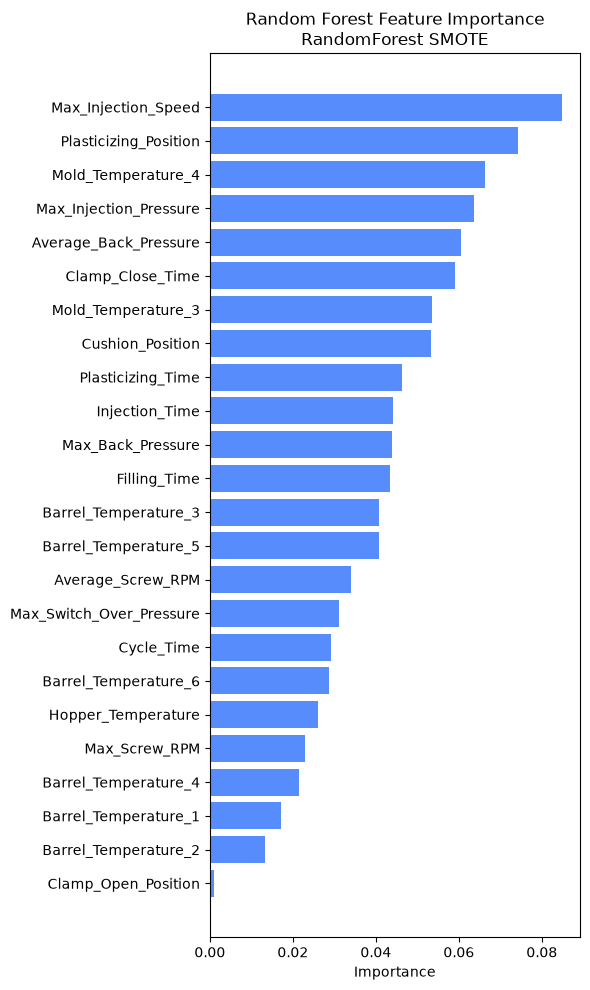

In [18]:
importance_tables=show_random_forest_feature_importance(model_dict, x_train.columns)

#### SMOTE 파라미터 조정

#### 데이터 전처리

In [19]:
# 중복값 제거
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)

# CN7, RG3 제외 삭제
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

# 불필요한 변수 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2',
               'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL',
               'PART_NAME', 'Reason', 'Switch_Over_Position', 'TimeStamp', '_id']

final_df=drop_part.drop(columns=drop_columns)

# PassOrFail 인코딩
final_df['PassOrFail']=final_df['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

# 데이터 분할
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=y, random_state=0)

# 스케일링
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# SMOTE Sampling_strategy
smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4184, 24) (4184,)
After
(4549, 24) (4549,)


#### 모델 학습

In [20]:
# 학습 모델 저장
model_dict={}

# Random Forest
smote_rf=RandomForestClassifier(n_estimators=1000, random_state=0)
smote_rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest SMOTE St=0.1']=smote_rf

# Bagging
smote_bag=BaggingClassifier(n_estimators=1000, random_state=0)
smote_bag.fit(x_train_smote, y_train_smote)
model_dict['Bagging SMOTE St=0.1']=smote_bag

# XGBoost
smote_xgb=XGBClassifier(n_estimators=1000, random_state=0)
smote_xgb.fit(x_train_smote, y_train_smote)
model_dict['XGBoost SMOTE St=0.1']=smote_xgb

#### 예측

RandomForest SMOTE St=0.1
Accuracy: 0.9837476099426387
Average Precision: 0.43609974019232134
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.37      0.58      0.45        12

    accuracy                           0.98      1046
   macro avg       0.68      0.79      0.72      1046
weighted avg       0.99      0.98      0.99      1046

Bagging SMOTE St=0.1
Accuracy: 0.9837476099426387
Average Precision: 0.4193462039417067
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.37      0.58      0.45        12

    accuracy                           0.98      1046
   macro avg       0.68      0.79      0.72      1046
weighted avg       0.99      0.98      0.99      1046

XGBoost SMOTE St=0.1
Accuracy: 0.9837476099426387
Average Precision: 0.3009241456093764
Classification Report
          

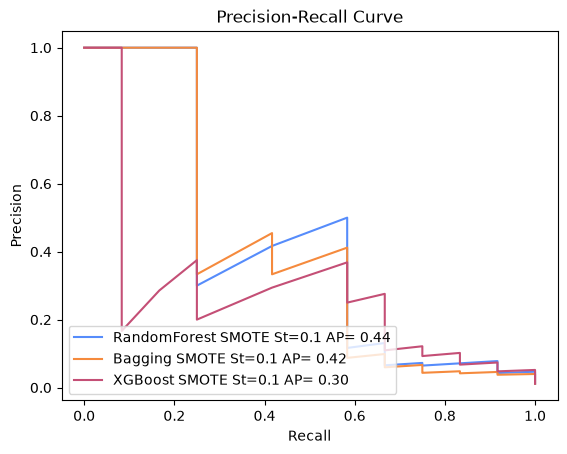

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.351758
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.450183
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.445244
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.373841
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.436100
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.419346
9,XGBoost SMOTE St=0.1,0.368421,0.583333,0.451613,0.300924


In [21]:
# model_dict의 키를 모델명으로 그대로 사용해 예측 및 평가
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest SMOTE St=0.1 - Random Forest Feature Importance


,Feature,Importance
0,Cushion_Position,0.079532
1,Max_Injection_Speed,0.065132
2,Max_Injection_Pressure,0.058881
3,Clamp_Close_Time,0.056557
4,Mold_Temperature_3,0.051517
5,Mold_Temperature_4,0.050668
6,Average_Back_Pressure,0.050389
7,Barrel_Temperature_5,0.050071
8,Plasticizing_Time,0.049294
9,Filling_Time,0.047042


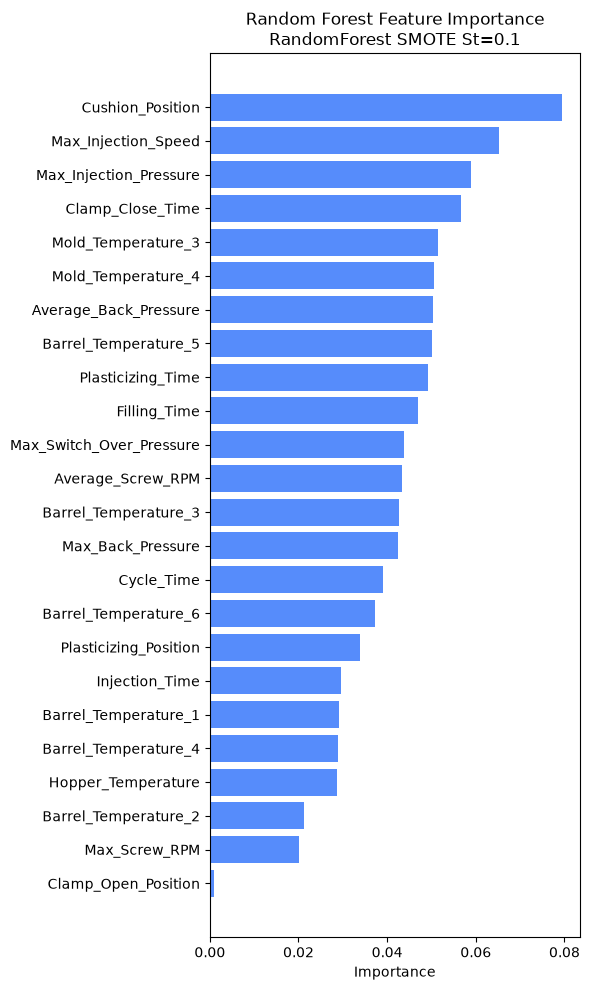

In [22]:
importance_tables = show_random_forest_feature_importance(
    model_dict, x_train.columns
)

### 제품명 변수 추가

#### 데이터 전처리

In [23]:
# 중복값 제거
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)

# CN7, RG3 제외 삭제
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

# CN7, RG3 구분하는 변수 추가
drop_part['Part']=drop_part['PART_NAME'].str[:3]

# 불필요한 변수 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11',
              'Mold_Temperature_12', 'Mold_Temperature_2','Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7',
              'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL','PART_NAME', 'Reason',
              'Switch_Over_Position', 'TimeStamp', '_id']

drop_col=drop_part.drop(columns=drop_columns)

# PassOrFail 인코딩
drop_col['PassOrFail']=drop_col['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

# 더미변수 생성
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

#### 모델 학습

In [24]:
model_dict={}
# Random Forest
rf=RandomForestClassifier(n_estimators=1000, random_state=0)
rf.fit(x_train_scaled, y_train)
model_dict['RandomForest PART_NAME_1']=rf

#### 예측

RandomForest PART_NAME_1
Accuracy: 0.9818355640535373
Average Precision: 0.44825143656946304
Classification Report
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.29      0.42      0.34        12

    accuracy                           0.98      1046
   macro avg       0.64      0.70      0.67      1046
weighted avg       0.99      0.98      0.98      1046



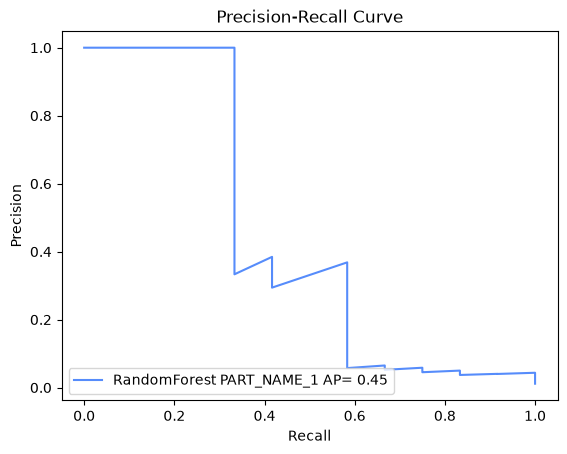

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.351758
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.450183
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.445244
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.373841
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.436100
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.419346
9,XGBoost SMOTE St=0.1,0.368421,0.583333,0.451613,0.300924


In [25]:
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

#### 데이터 전처리

In [26]:
# 중복값 제거
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)

# CN7, RG3 제외 삭제
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

# CN7, RG3 / LH, RH 구분하는 변수 추가
drop_part['Part']=drop_part['PART_NAME'].str[:3]+drop_part['PART_NAME'].str[-2:]

# 불필요한 변수 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11',
              'Mold_Temperature_12', 'Mold_Temperature_2','Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7',
              'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL','PART_NAME', 'Reason',
              'Switch_Over_Position', 'TimeStamp', '_id']

drop_col=drop_part.drop(columns=drop_columns)

# PassOrFail 인코딩
drop_col['PassOrFail']=drop_col['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

# 더미변수 생성
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(final_df.drop(columns='PassOrFail'), final_df['PassOrFail'], test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

#### 모델 학습

In [27]:
model_dict={}
# Random Forest
rf=RandomForestClassifier(n_estimators=1000, random_state=0)
rf.fit(x_train_scaled, y_train)
model_dict['RandomForest PART_NAME_2']=rf

#### 예측

RandomForest PART_NAME_2
Accuracy: 0.9875717017208413
Average Precision: 0.5306388026492072
Classification Report
              precision    recall  f1-score   support

          양품       0.99      0.99      0.99      1034
          불량       0.45      0.42      0.43        12

    accuracy                           0.99      1046
   macro avg       0.72      0.71      0.71      1046
weighted avg       0.99      0.99      0.99      1046



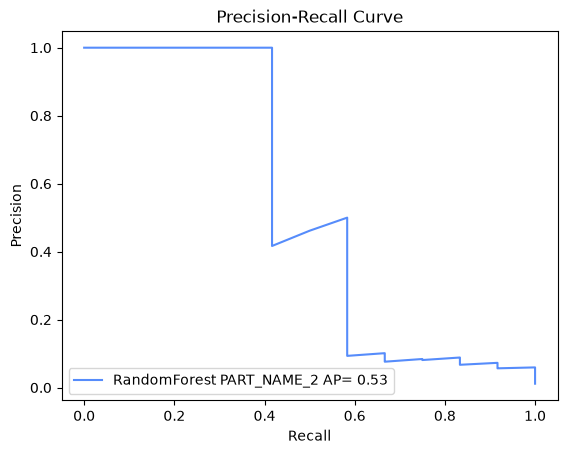

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.351758
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.450183
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.445244
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.373841
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.436100
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.419346
9,XGBoost SMOTE St=0.1,0.368421,0.583333,0.451613,0.300924


In [28]:
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest PART_NAME_2 - Random Forest Feature Importance


,Feature,Importance
0,Cushion_Position,0.053083
1,Barrel_Temperature_1,0.052742
2,Barrel_Temperature_4,0.052124
3,Max_Injection_Speed,0.051335
4,Max_Switch_Over_Pressure,0.049651
5,Mold_Temperature_4,0.048946
6,Hopper_Temperature,0.048485
7,Max_Injection_Pressure,0.045273
8,Plasticizing_Time,0.045220
9,Average_Back_Pressure,0.044432


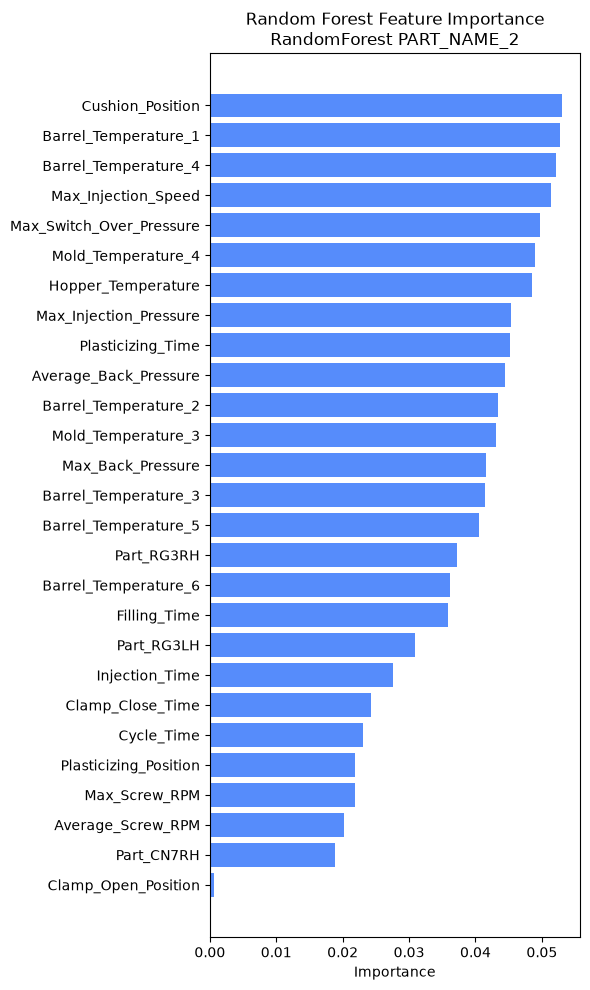

In [29]:
importance_tables = show_random_forest_feature_importance(
    model_dict, x_train.columns
)

### PART_NAME + Class Weight

#### 데이터 전처리

In [30]:
# 중복값 제거
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)

# CN7, RG3 제외 삭제
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

# CN7, RG3 / LH, RH 구분하는 변수 추가
drop_part['Part']=drop_part['PART_NAME'].str[:3]+drop_part['PART_NAME'].str[-2:]

# 불필요한 변수 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11',
              'Mold_Temperature_12', 'Mold_Temperature_2','Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7',
              'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL','PART_NAME', 'Reason',
              'Switch_Over_Position', 'TimeStamp', '_id']

drop_col=drop_part.drop(columns=drop_columns)

# PassOrFail 인코딩
drop_col['PassOrFail']=drop_col['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

# 더미변수 생성
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

#### 모델 학습

In [31]:
model_dict={}
# Random Forest
rf=RandomForestClassifier(n_estimators=1000, class_weight='balanced', min_samples_leaf=2, n_jobs=1,random_state=0)
rf.fit(x_train_scaled, y_train)
model_dict['RandomForest PART_NAME + Balanced']=rf

#### 예측

RandomForest PART_NAME + Balanced
Accuracy: 0.988527724665392
Average Precision: 0.5734219926010969
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.50      0.67      0.57        12

    accuracy                           0.99      1046
   macro avg       0.75      0.83      0.78      1046
weighted avg       0.99      0.99      0.99      1046



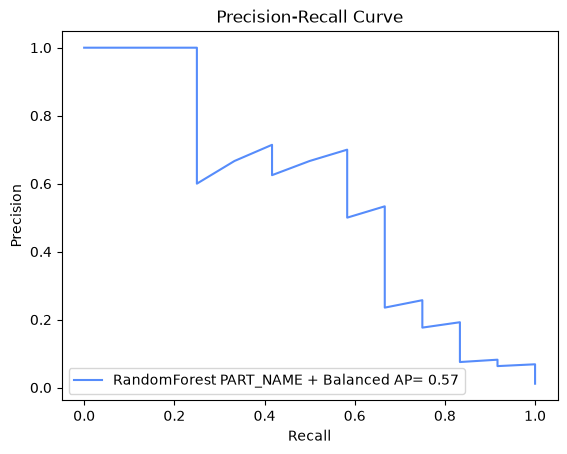

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.351758
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.450183
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.445244
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.373841
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.436100
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.419346
9,XGBoost SMOTE St=0.1,0.368421,0.583333,0.451613,0.300924


In [32]:
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest PART_NAME + Balanced - Random Forest Feature Importance


,Feature,Importance
0,Plasticizing_Position,0.076610
1,Max_Injection_Speed,0.067743
2,Mold_Temperature_4,0.066553
3,Max_Injection_Pressure,0.063811
4,Injection_Time,0.060195
5,Mold_Temperature_3,0.052689
6,Plasticizing_Time,0.052284
7,Clamp_Close_Time,0.050878
8,Filling_Time,0.049541
9,Average_Back_Pressure,0.048371


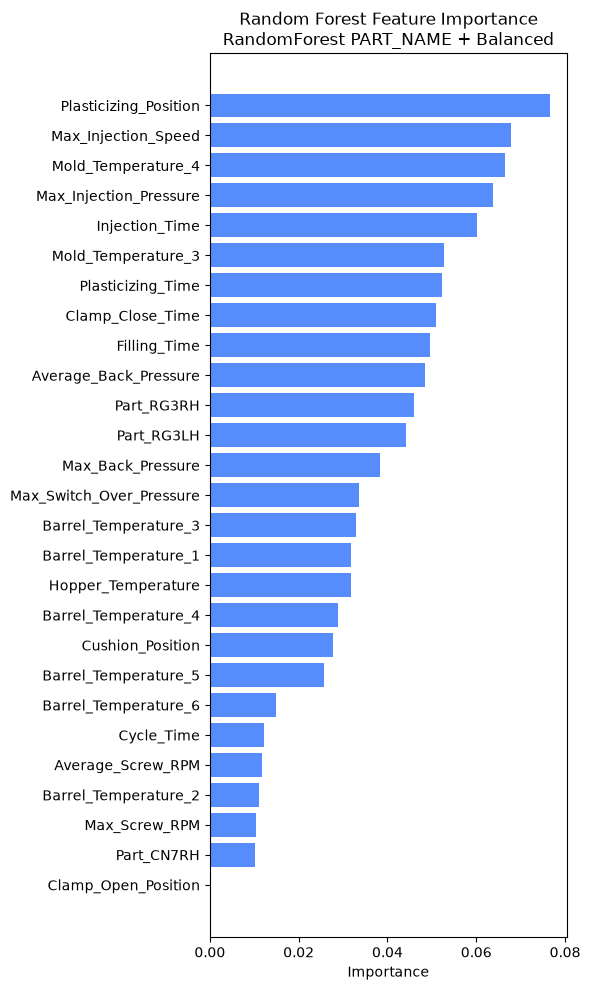

In [33]:
importance_tables = show_random_forest_feature_importance(
    model_dict, x_train.columns
)

### SMOTE + PART_NAME

#### 데이터 전처리

In [34]:
# 중복값 제거
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)

# CN7, RG3 제외 삭제
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

# CN7, RG3 / LH, RH 구분하는 변수 추가
drop_part['Part']=drop_part['PART_NAME'].str[:3]+drop_part['PART_NAME'].str[-2:]

# 불필요한 변수 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11',
              'Mold_Temperature_12', 'Mold_Temperature_2','Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7',
              'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL','PART_NAME', 'Reason',
              'Switch_Over_Position', 'TimeStamp', '_id']

drop_col=drop_part.drop(columns=drop_columns)

# PassOrFail 인코딩
drop_col['PassOrFail']=drop_col['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

# 더미변수 생성
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# SMOTE
smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4184, 27) (4184,)
After
(4549, 27) (4549,)


#### 모델 학습

In [35]:
# 학습 모델 저장
model_dict={}

# Random Forest
smote_rf=RandomForestClassifier(n_estimators=1000, random_state=0)
smote_rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest PART_NAME+SMOTE St=0.1']=smote_rf

# Bagging
smote_bag=BaggingClassifier(n_estimators=1000, random_state=0)
smote_bag.fit(x_train_smote, y_train_smote)
model_dict['Bagging PART_NAME+SMOTE St=0.1']=smote_bag

# XGBoost
smote_xgb=XGBClassifier(n_estimators=1000, random_state=0)
smote_xgb.fit(x_train_smote, y_train_smote)
model_dict['XGBoost PART_NAME+SMOTE St=0.1']=smote_xgb

#### 예측

RandomForest PART_NAME+SMOTE St=0.1
Accuracy: 0.9894837476099426
Average Precision: 0.649229117934154
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.54      0.58      0.56        12

    accuracy                           0.99      1046
   macro avg       0.77      0.79      0.78      1046
weighted avg       0.99      0.99      0.99      1046

Bagging PART_NAME+SMOTE St=0.1
Accuracy: 0.988527724665392
Average Precision: 0.6253139675766879
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.50      0.58      0.54        12

    accuracy                           0.99      1046
   macro avg       0.75      0.79      0.77      1046
weighted avg       0.99      0.99      0.99      1046

XGBoost PART_NAME+SMOTE St=0.1
Accuracy: 0.9904397705544933
Average Precision: 0.5275789783103119
Class

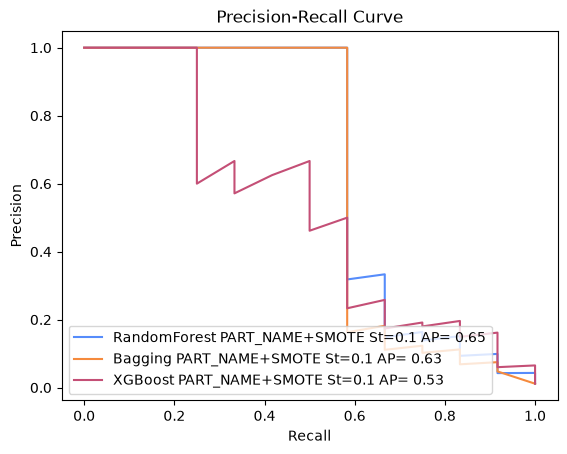

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.351758
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.450183
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.445244
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.373841
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.436100
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.419346
9,XGBoost SMOTE St=0.1,0.368421,0.583333,0.451613,0.300924


In [36]:
# model_dict의 키를 모델명으로 그대로 사용해 예측 및 평가
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest PART_NAME+SMOTE St=0.1 - Random Forest Feature Importance


,Feature,Importance
0,Cushion_Position,0.077654
1,Max_Injection_Speed,0.063298
2,Clamp_Close_Time,0.058119
3,Max_Injection_Pressure,0.054639
4,Mold_Temperature_3,0.051430
5,Part_RG3RH,0.050146
6,Barrel_Temperature_5,0.047869
7,Average_Back_Pressure,0.046461
8,Mold_Temperature_4,0.046065
9,Filling_Time,0.043781


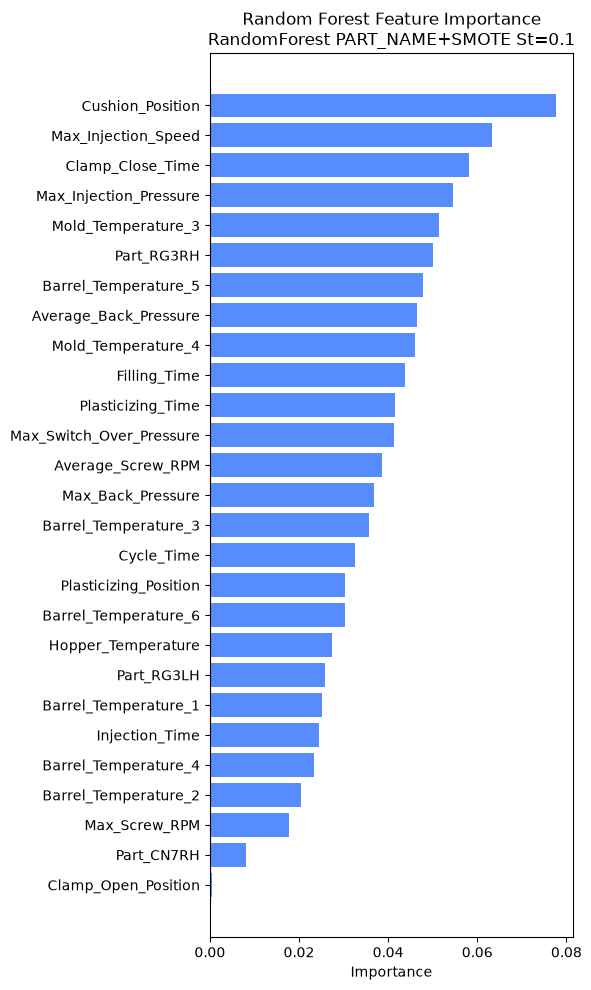

In [37]:
# model_dict에 다른 모델이 있어도 Random Forest만 표와 그래프로 출력
importance_tables = show_random_forest_feature_importance(model_dict, x_train.columns)

### SMOTE + Class Weight

#### 데이터 전처리

In [38]:
# 중복값 제거
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)

# CN7, RG3 제외 삭제
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

# CN7, RG3 제외 삭제
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

# 불필요한 변수 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11', 'Mold_Temperature_12', 'Mold_Temperature_2',
               'Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7', 'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL',
               'PART_NAME', 'Reason', 'Switch_Over_Position', 'TimeStamp', '_id']

final_df=drop_part.drop(columns=drop_columns)

# PassOrFail 인코딩
final_df['PassOrFail']=final_df['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

# 데이터 분할
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=y, random_state=0)

# 스케일링
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# SMOTE Sampling_strategy
smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4184, 24) (4184,)
After
(4549, 24) (4549,)


#### 모델 학습

In [39]:
model_dict={}
# Random Forest
rf=RandomForestClassifier(n_estimators=1000, class_weight='balanced', min_samples_leaf=2, n_jobs=1,random_state=0)
rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest SMOTE St=0.1 + Balanced']=rf

#### 예측

RandomForest SMOTE St=0.1 + Balanced
Accuracy: 0.982791586998088
Average Precision: 0.4070254235202239
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.35      0.58      0.44        12

    accuracy                           0.98      1046
   macro avg       0.67      0.79      0.71      1046
weighted avg       0.99      0.98      0.98      1046



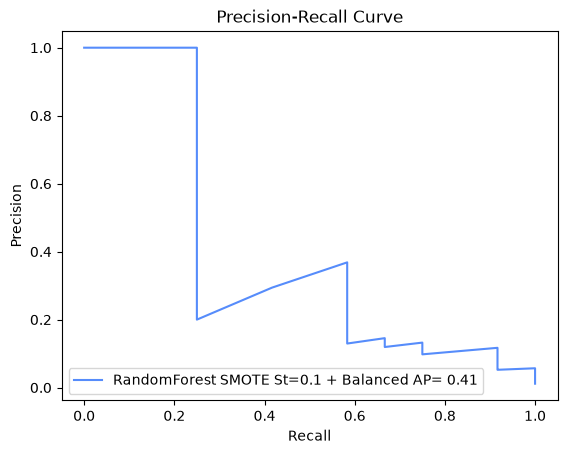

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.351758
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.450183
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.445244
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.373841
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.436100
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.419346
9,XGBoost SMOTE St=0.1,0.368421,0.583333,0.451613,0.300924


In [40]:
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest SMOTE St=0.1 + Balanced - Random Forest Feature Importance


,Feature,Importance
0,Max_Injection_Speed,0.079856
1,Plasticizing_Position,0.077335
2,Average_Back_Pressure,0.069392
3,Clamp_Close_Time,0.064886
4,Mold_Temperature_3,0.062539
5,Max_Back_Pressure,0.057166
6,Max_Injection_Pressure,0.055909
7,Mold_Temperature_4,0.055115
8,Plasticizing_Time,0.044225
9,Filling_Time,0.042606


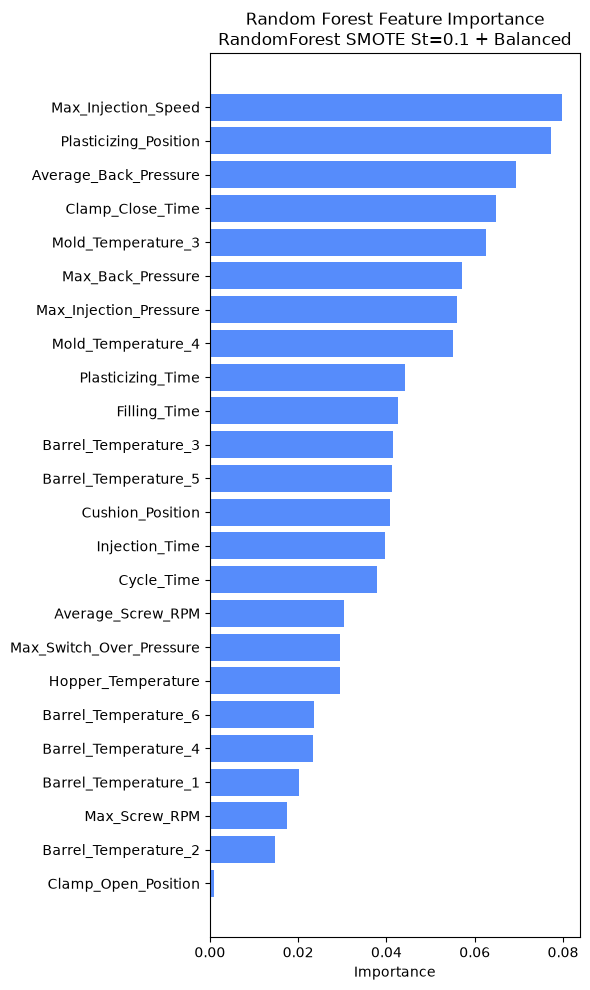

In [41]:
importance_tables = show_random_forest_feature_importance(
    model_dict, x_train.columns
)

### SMOTE + PART_NAME + Class Weight

#### 데이터 전처리

In [42]:
# 중복값 제거
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)

# CN7, RG3 제외 삭제
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

# CN7, RG3 / LH, RH 구분하는 변수 추가
drop_part['Part']=drop_part['PART_NAME'].str[:3]+drop_part['PART_NAME'].str[-2:]

# 불필요한 변수 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_CD', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11',
              'Mold_Temperature_12', 'Mold_Temperature_2','Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7',
              'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL','PART_NAME', 'Reason',
              'Switch_Over_Position', 'TimeStamp', '_id']

drop_col=drop_part.drop(columns=drop_columns)

# PassOrFail 인코딩
drop_col['PassOrFail']=drop_col['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

# 더미변수 생성
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)
x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=final_df['PassOrFail'], random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# SMOTE
smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4184, 27) (4184,)
After
(4549, 27) (4549,)


#### 모델 학습

In [43]:
# 학습 모델 저장
model_dict={}

# Random Forest
smote_rf=RandomForestClassifier(n_estimators=1000, class_weight='balanced', min_samples_leaf=2, n_jobs=1,random_state=0)
smote_rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest PART_NAME+SMOTE St=0.1+Balanced']=smote_rf

RandomForest PART_NAME+SMOTE St=0.1+Balanced
Accuracy: 0.98565965583174
Average Precision: 0.5770654296491787
Classification Report
              precision    recall  f1-score   support

          양품       1.00      0.99      0.99      1034
          불량       0.41      0.58      0.48        12

    accuracy                           0.99      1046
   macro avg       0.70      0.79      0.74      1046
weighted avg       0.99      0.99      0.99      1046



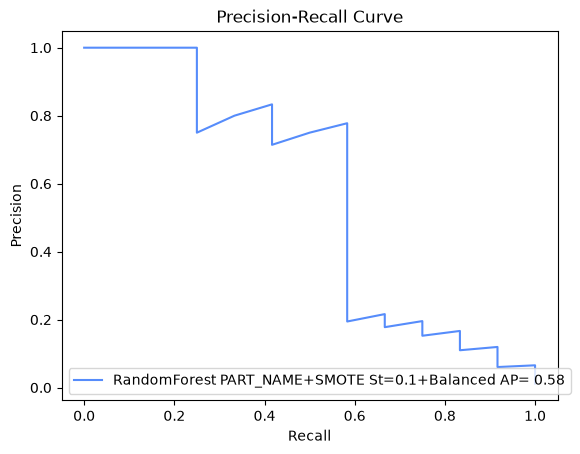

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.351758
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.450183
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.445244
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.373841
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.436100
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.419346
9,XGBoost SMOTE St=0.1,0.368421,0.583333,0.451613,0.300924


In [44]:
# model_dict의 키를 모델명으로 그대로 사용해 예측 및 평가
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest PART_NAME+SMOTE St=0.1+Balanced - Random Forest Feature Importance


,Feature,Importance
0,Max_Injection_Speed,0.083431
1,Plasticizing_Position,0.069011
2,Max_Injection_Pressure,0.068797
3,Average_Back_Pressure,0.066810
4,Clamp_Close_Time,0.059215
5,Max_Back_Pressure,0.058663
6,Mold_Temperature_3,0.057237
7,Mold_Temperature_4,0.056245
8,Filling_Time,0.047144
9,Injection_Time,0.046235


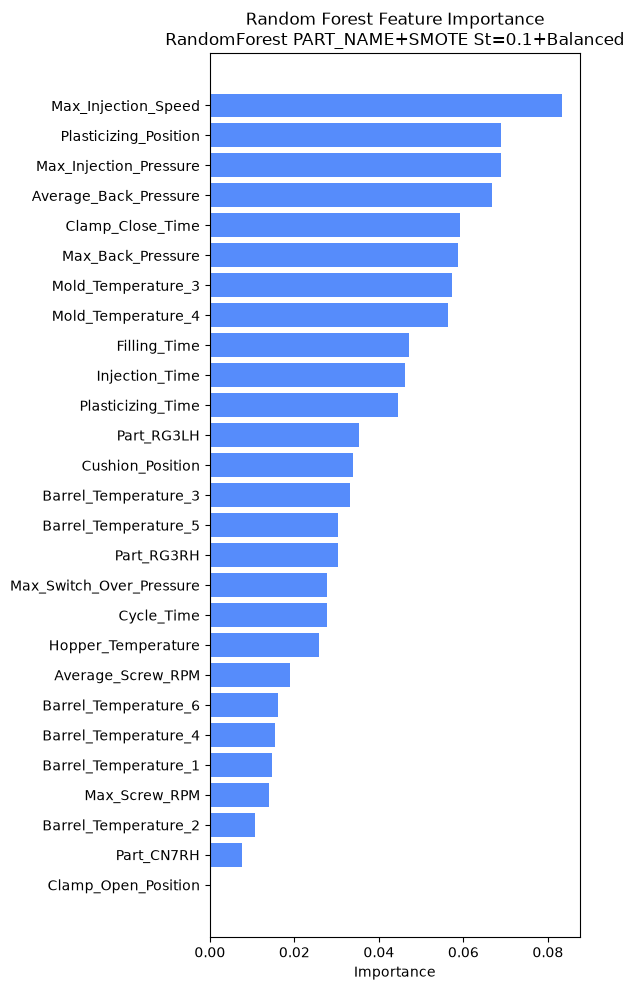

In [45]:
# model_dict에 다른 모델이 있어도 Random Forest만 표와 그래프로 출력
importance_tables = show_random_forest_feature_importance(model_dict, x_train.columns)

### PART_NAME + SMOTE + 파생변수 추가

#### 데이터 전처리

In [46]:
# 중복값 제거
drop_dup=labeled.drop_duplicates(keep='first', ignore_index=True)

# CN7, RG3 제외 삭제
drop_part=drop_dup[drop_dup['PART_NAME'].str.startswith(("CN7", "RG3"))]

# CN7, RG3 / LH, RH 구분하는 변수 추가
drop_part['Part']=drop_part['PART_NAME'].str[:3]+drop_part['PART_NAME'].str[-2:]

# TimeStamp 정렬
sort_df=drop_part.copy().sort_values('TimeStamp', ignore_index=True)



# 불필요한 변수 삭제
drop_columns=['Barrel_Temperature_7', 'EQUIP_NAME', 'Mold_Temperature_1', 'Mold_Temperature_10', 'Mold_Temperature_11',
              'Mold_Temperature_12', 'Mold_Temperature_2','Mold_Temperature_5', 'Mold_Temperature_6', 'Mold_Temperature_7',
              'Mold_Temperature_8', 'Mold_Temperature_9', 'PART_FACT_PLAN_DATE', 'PART_FACT_SERIAL','Reason', 'Switch_Over_Position', 'TimeStamp', '_id']

drop_col=sort_df.drop(columns=drop_columns)

# PassOrFail 인코딩
drop_col['PassOrFail']=drop_col['PassOrFail'].map({'Y':0, 'N':1})
# 양품: 0, 불량: 1

# 더미변수 생성
final_df = pd.get_dummies(data = drop_col, columns = ['Part'], drop_first=True)

# 파생변수 추가
final_df['Barrel_Temp_Range']=(final_df[[f'Barrel_Temperature_{i}' for i in range(1, 7)]].max(axis=1)
                                      - final_df[[f'Barrel_Temperature_{i}' for i in range(1, 7)]].min(axis=1))

final_df['Barrel_Temp_Std'] = final_df[[f'Barrel_Temperature_{i}' for i in range(1, 7)]].std(axis=1)

final_df['Mold_Temp_Range']=(final_df[[f'Mold_Temperature_{i}' for i in range(3, 5)]].max(axis=1)
                                      - final_df[[f'Barrel_Temperature_{i}' for i in range(1, 7)]].min(axis=1))

final_df['Mold_Temp_Std'] = final_df[[f'Mold_Temperature_{i}' for i in range(3, 5)]].std(axis=1)

for col in ['Injection_Time', 'Cycle_Time',
            'Max_Injection_Pressure', 'Cushion_Position']:
    final_df[f'{col}_diff'] = final_df[col].diff()
    final_df[f'{col}_rolling_mean_5'] = final_df.groupby(['EQUIP_CD', 'PART_NAME'])[col].transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean())
    final_df[f'{col}_rolling_std_5'] = final_df.groupby(['EQUIP_CD', 'PART_NAME'])[col].transform(lambda x: x.shift(1).rolling(5, min_periods=1).std())

drop_columns=['EQUIP_CD', 'PART_NAME']
final_df=final_df.drop(columns=drop_columns)
final_df=final_df.dropna(ignore_index=True)

x=final_df.drop(columns='PassOrFail')
y=final_df['PassOrFail']

# 데이터 분할
x_train, x_test, y_train, y_test=train_test_split(x, y, test_size=0.2, stratify=y, random_state=0)

# 스케일러
scaler=StandardScaler()

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

# SMOTE
smote=SMOTE(sampling_strategy=0.1, k_neighbors=3, random_state=0)
print("Before")
print(x_train_scaled.shape, y_train.shape)

x_train_smote, y_train_smote=smote.fit_resample(x_train_scaled, y_train)
print("After")
print(x_train_smote.shape, y_train_smote.shape)

Before
(4177, 43) (4177,)
After
(4541, 43) (4541,)


#### 모델 학습

In [47]:
# 학습 모델 저장
model_dict={}

# Random Forest
rf=RandomForestClassifier(n_estimators=1000, random_state=0)
rf.fit(x_train_smote, y_train_smote)
model_dict['RandomForest PART_NAME+SMOTE St=0.1+Feature']=rf

#### 예측

RandomForest PART_NAME+SMOTE St=0.1+Feature
Accuracy: 0.9894736842105263
Average Precision: 0.45384550994165784
Classification Report
              precision    recall  f1-score   support

          양품       0.99      1.00      0.99      1033
          불량       0.57      0.33      0.42        12

    accuracy                           0.99      1045
   macro avg       0.78      0.67      0.71      1045
weighted avg       0.99      0.99      0.99      1045



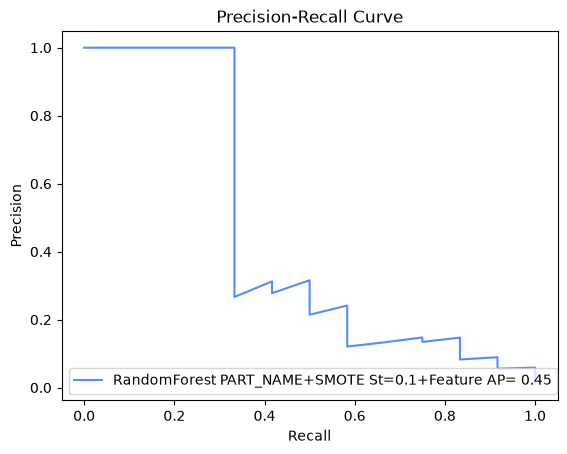

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
0,RandomForest Baseline,0.294118,0.416667,0.344828,0.452946
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109
3,RandomForest Balanced,0.350000,0.583333,0.437500,0.351758
4,RandomForest SMOTE,0.294118,0.416667,0.344828,0.450183
5,Bagging SMOTE,0.304348,0.583333,0.400000,0.445244
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.373841
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.436100
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.419346
9,XGBoost SMOTE St=0.1,0.368421,0.583333,0.451613,0.300924


In [48]:
# model_dict의 키를 모델명으로 그대로 사용해 예측 및 평가
result_df = evaluate_models(model_dict, x_test_scaled, y_test, result_df)
result_df

RandomForest PART_NAME+SMOTE St=0.1+Feature - Random Forest Feature Importance


,Feature,Importance
0,Cushion_Position,0.058928
1,Max_Injection_Speed,0.049050
2,Injection_Time_rolling_std_5,0.044445
3,Mold_Temperature_3,0.040007
4,Filling_Time,0.038117
5,Clamp_Close_Time,0.036287
6,Average_Back_Pressure,0.033355
7,Part_RG3RH,0.032436
8,Injection_Time_rolling_mean_5,0.031786
9,Max_Injection_Pressure,0.031591


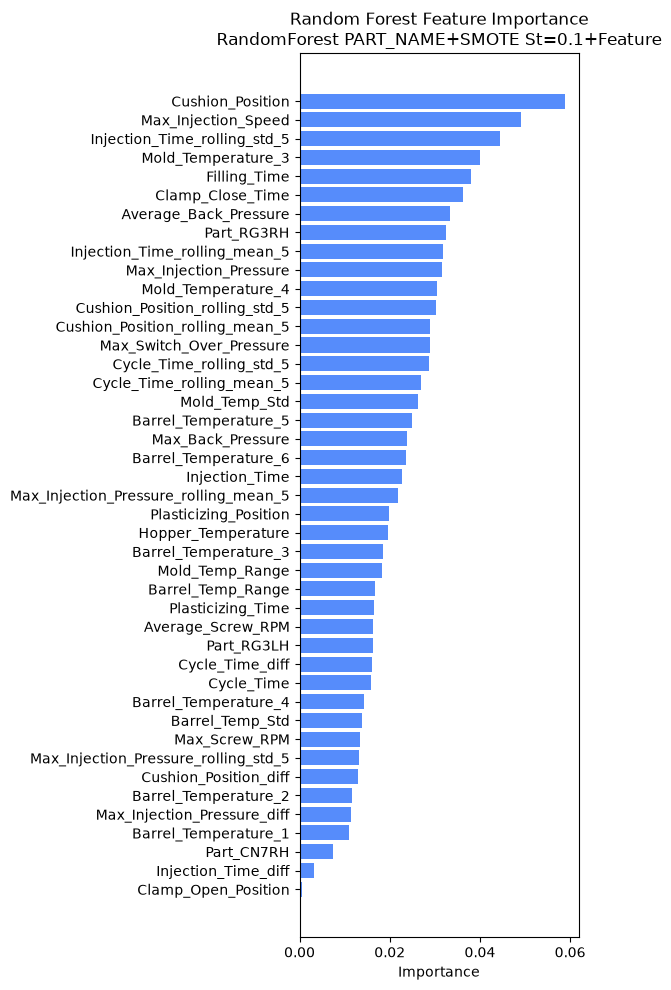

In [49]:
# model_dict에 다른 모델이 있어도 Random Forest만 표와 그래프로 출력
importance_tables = show_random_forest_feature_importance(model_dict, x_train.columns)

# 모델링 결과 요약

In [50]:
result_df.sort_values(['Defect Recall', 'Defect F1 Score', 'Average Precision'], ascending=False)

,Model,Defect Precision,Defect Recall,Defect F1 Score,Average Precision
12,RandomForest PART_NAME + Balanced,0.500000,0.666667,0.571429,0.573422
13,RandomForest PART_NAME+SMOTE St=0.1,0.538462,0.583333,0.560000,0.649229
14,Bagging PART_NAME+SMOTE St=0.1,0.500000,0.583333,0.538462,0.625314
17,RandomForest PART_NAME+SMOTE St=0.1+Balanced,0.411765,0.583333,0.482759,0.577065
7,RandomForest SMOTE St=0.1,0.368421,0.583333,0.451613,0.436100
8,Bagging SMOTE St=0.1,0.368421,0.583333,0.451613,0.419346
6,XGBoost SMOTE,0.368421,0.583333,0.451613,0.373841
9,XGBoost SMOTE St=0.1,0.368421,0.583333,0.451613,0.300924
1,Bagging Baseline,0.368421,0.583333,0.451613,0.444408
2,XGBoost Baseline,0.368421,0.583333,0.451613,0.269109


In [60]:
result_df.to_csv('04_1_Imbalance_and_Feature_Experiments.csv', index=False)